In [17]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import os
from sklearn.utils import extmath
from module_utils import * 
import sys
sys.path.append('../utils')
from Structure import *
from data_collection import *
#######################     CONFIGURATIONS     ##########################
seed = 29
train = True
save = True

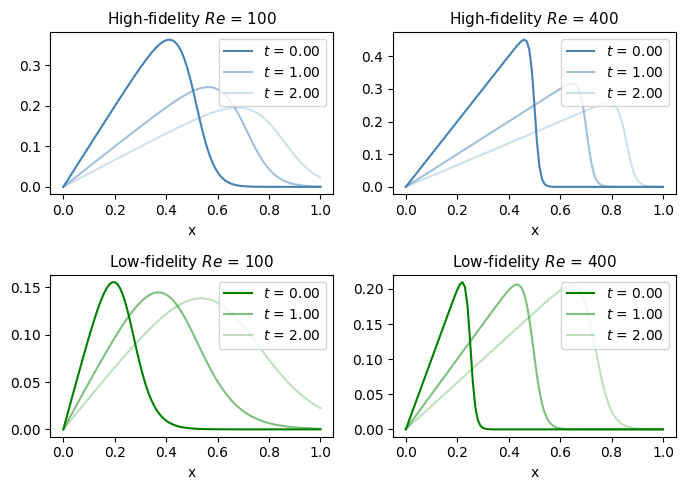

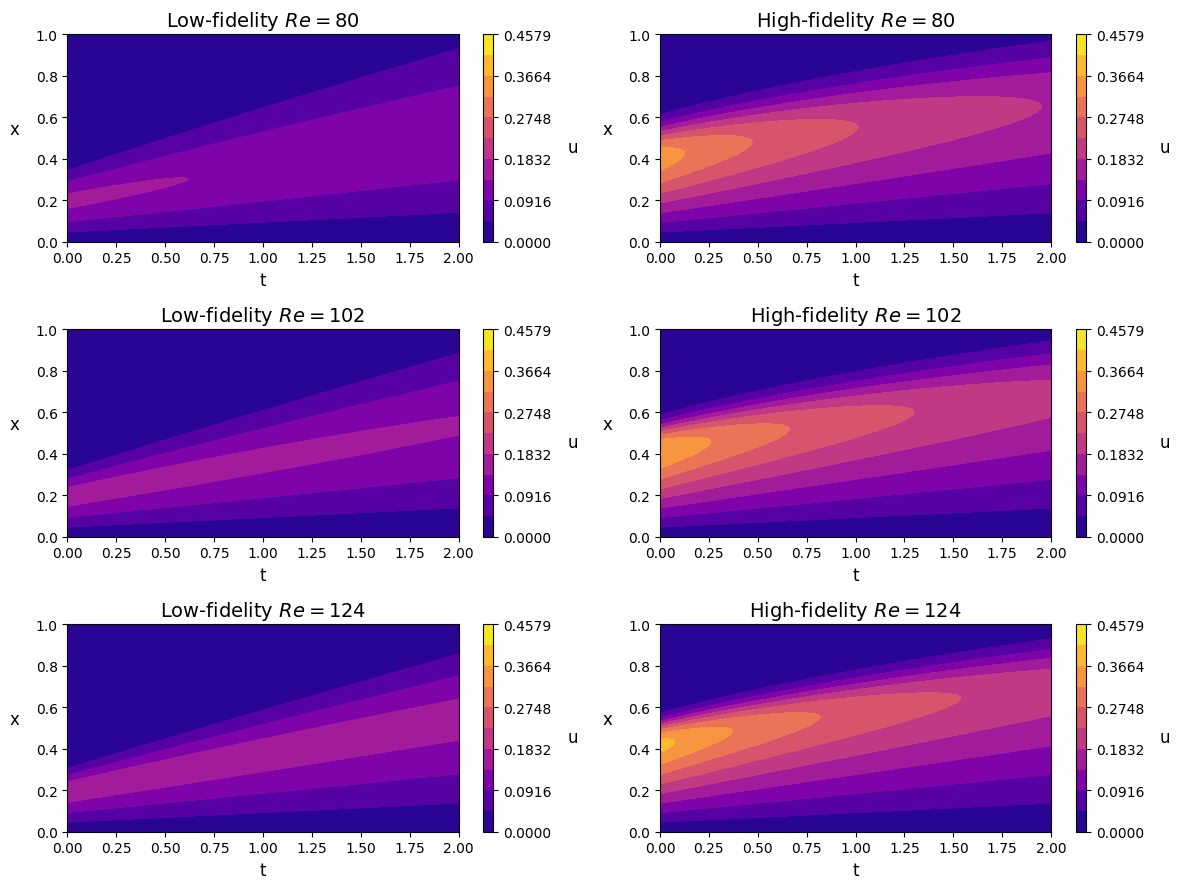

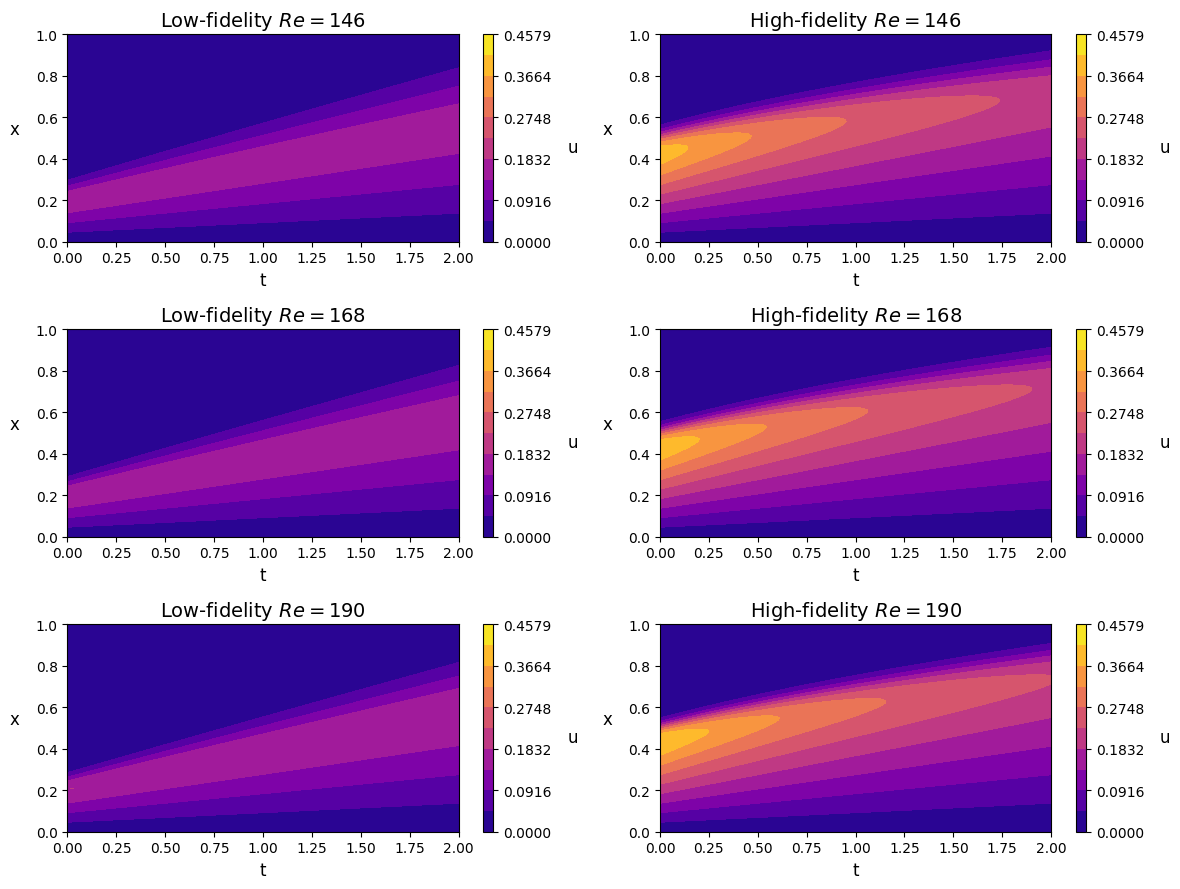

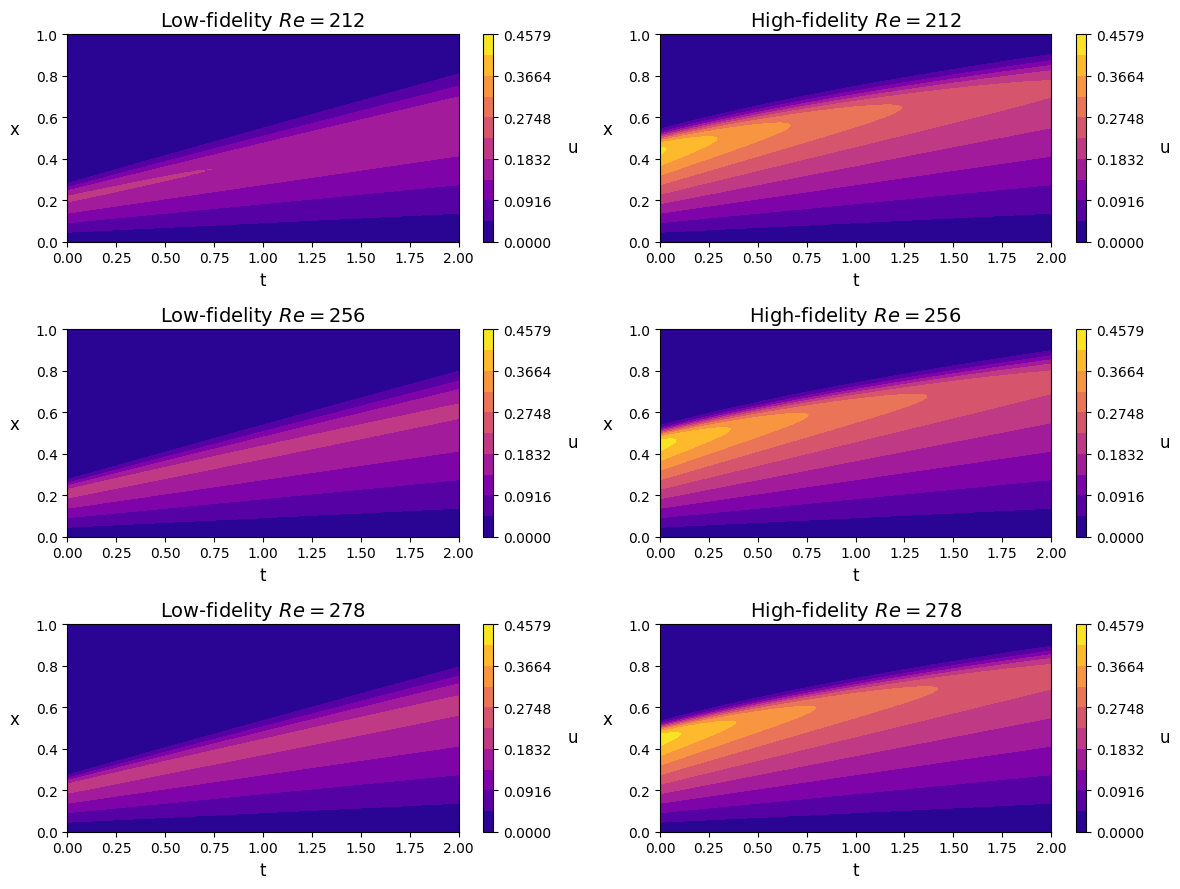

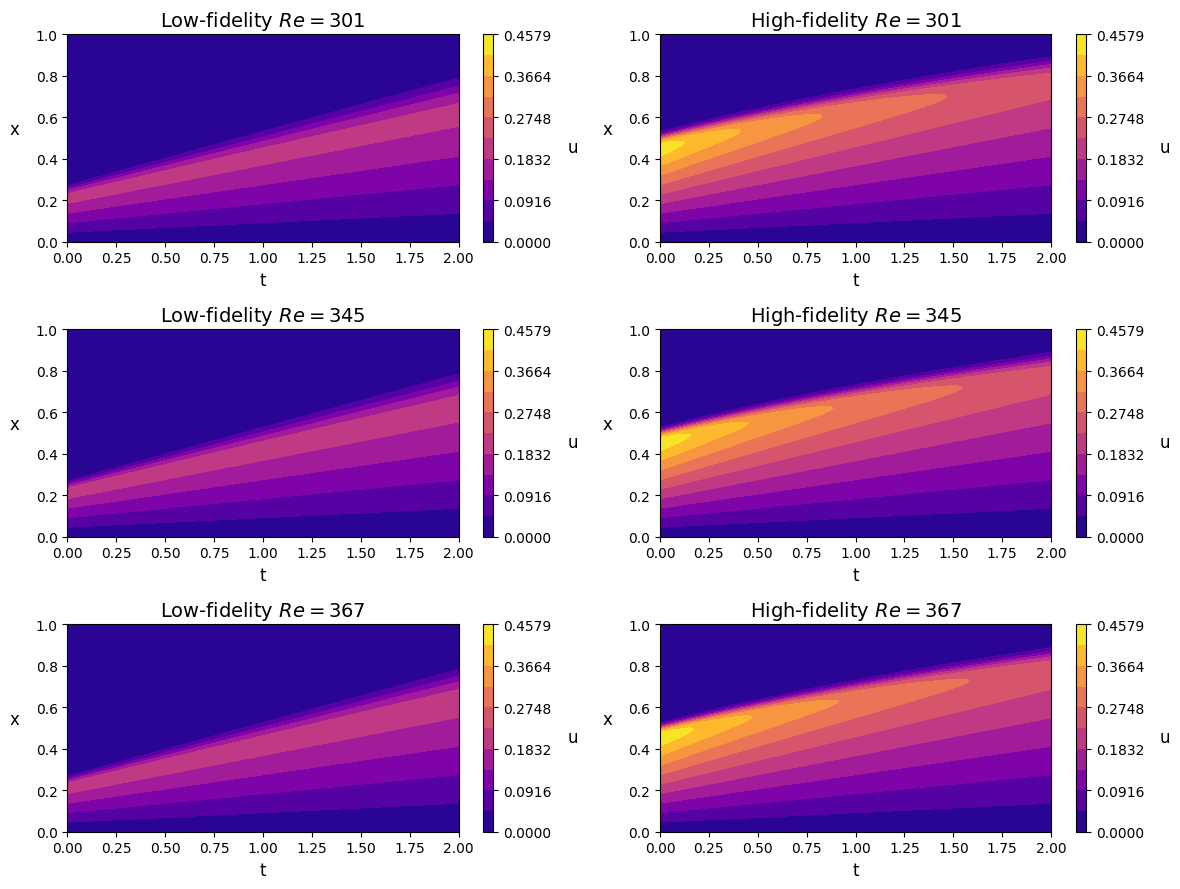

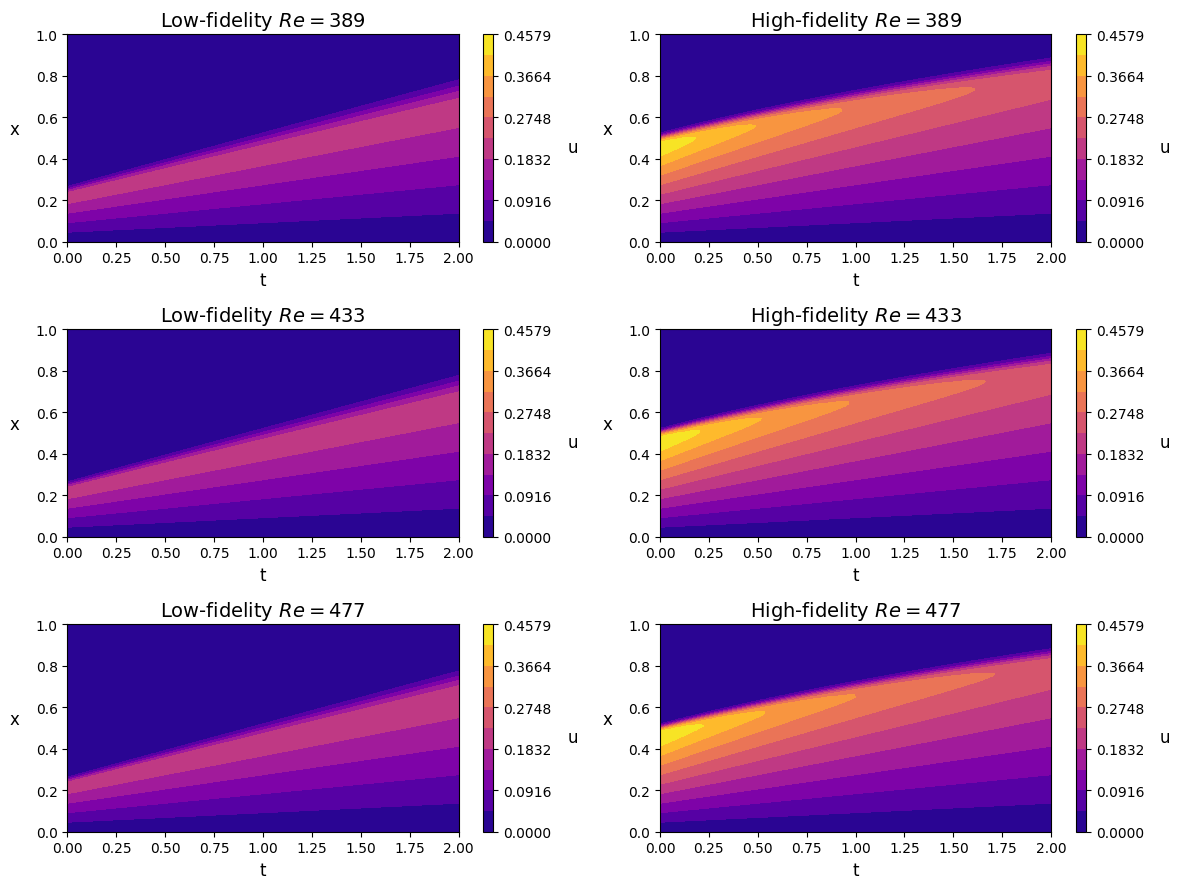

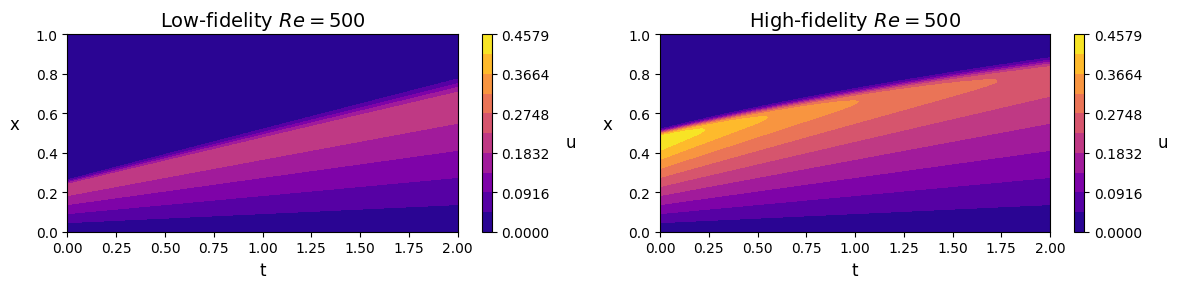

In [18]:
burger_eq = BurgerEquation(nh = 101, nt = 151, T= 2.0, L= 1.0, nre= 20, re_min = 80, re_max= 500, seed=seed)
burger_eq.generate_data()
burger_eq.plot_ground_truth_simulations()
burger_eq.plot_data()

In [3]:
burger_eq.basis=rom.basis
burger_eq.n_POD=16

NameError: name 'rom' is not defined

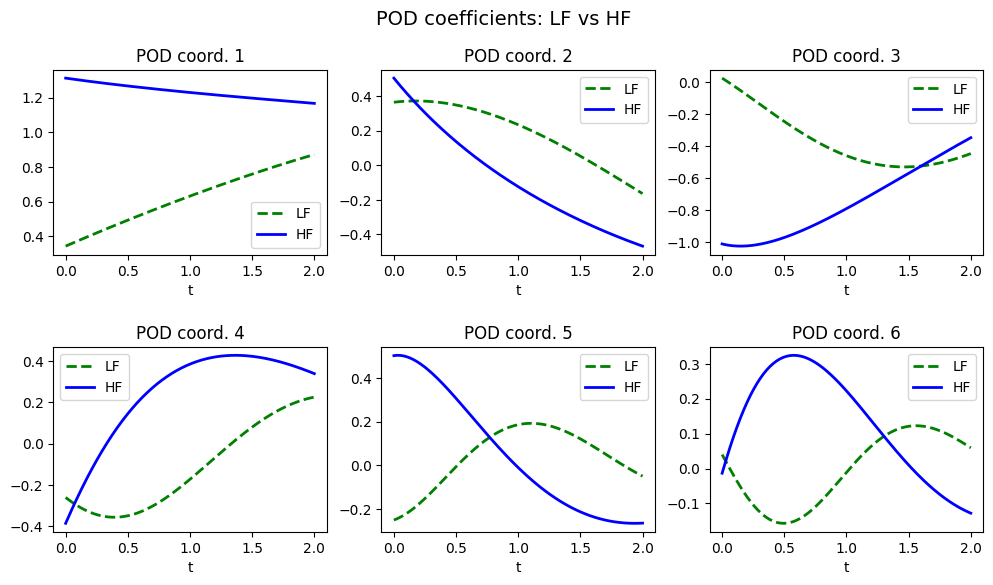

In [19]:
rom = ROM(burger_eq, n_POD=16)

input_train, output_train,input_test, output_test=rom.perform_POD()
rom.plot_POD_coefficients(ind_re=0)

[I 2024-08-16 03:02:58,381] A new study created in memory with name: no-name-6795e5b3-1c97-4147-915f-a99a39d827c1
[I 2024-08-16 03:06:20,228] Trial 3 finished with value: 0.001384207140134723 and parameters: {'nodes': 10, 'lr': 0.005226450736938897, 'opt': 'Adamax', 'sequence_length': 16, 'sequence_freq': 9, 'patience': 60, 'lay': 1, 'dropout': 0.397725298508094}. Best is trial 3 with value: 0.001384207140134723.
[I 2024-08-16 03:08:22,144] Trial 4 finished with value: 0.005632798440060836 and parameters: {'nodes': 35, 'lr': 0.00018695575961443363, 'opt': 'Adam', 'sequence_length': 33, 'sequence_freq': 6, 'patience': 92, 'lay': 3, 'dropout': 0.32418721252085364}. Best is trial 3 with value: 0.001384207140134723.
[I 2024-08-16 03:10:30,527] Trial 1 finished with value: 0.0026191598642285397 and parameters: {'nodes': 12, 'lr': 0.0011088656685158493, 'opt': 'Adam', 'sequence_length': 61, 'sequence_freq': 9, 'patience': 59, 'lay': 1, 'dropout': 0.44802982870941016}. Best is trial 3 with va

The function training took 210.612116 seconds.


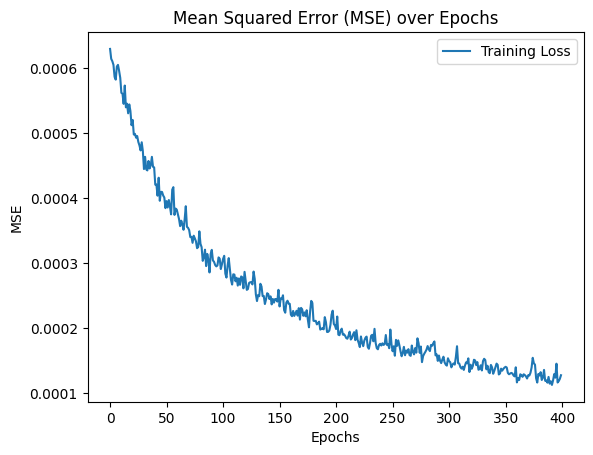

In [4]:

params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             #'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 500,
    "train": True,
    "do_HPO": True,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)
# Plot predicted POD coordinates
 # Re = 235

In [20]:

params_NN = {'nodes': 6, 
             'lr': 0.03076613412202823, 
             'opt': 'Adamax', 
             'sequence_length': 92, 
             'sequence_freq': 3, 
             'patience': 56, 
             'lay': 3, 
             'dropout': 0.14723750394236904}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 500,
    "train": True,
    "do_HPO": True,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)

[I 2024-08-17 03:52:21,343] A new study created in memory with name: no-name-bce96290-bfed-4e46-8957-280cba9d9cd0


The function training took 53.057864 seconds.


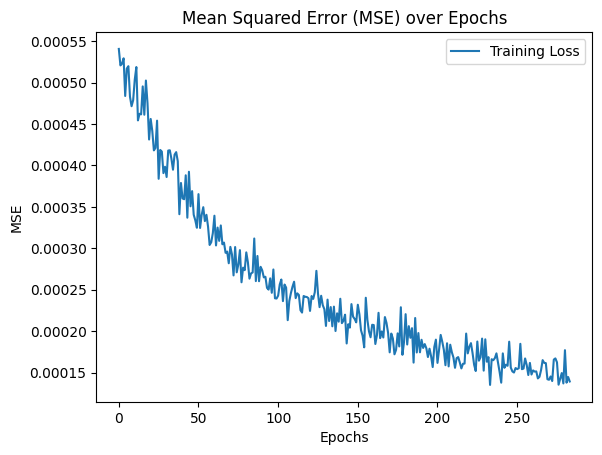

In [5]:

params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             #'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 500,
    "train": True,
    "do_HPO": False,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)
# Plot predicted POD coordinates
 # Re = 235

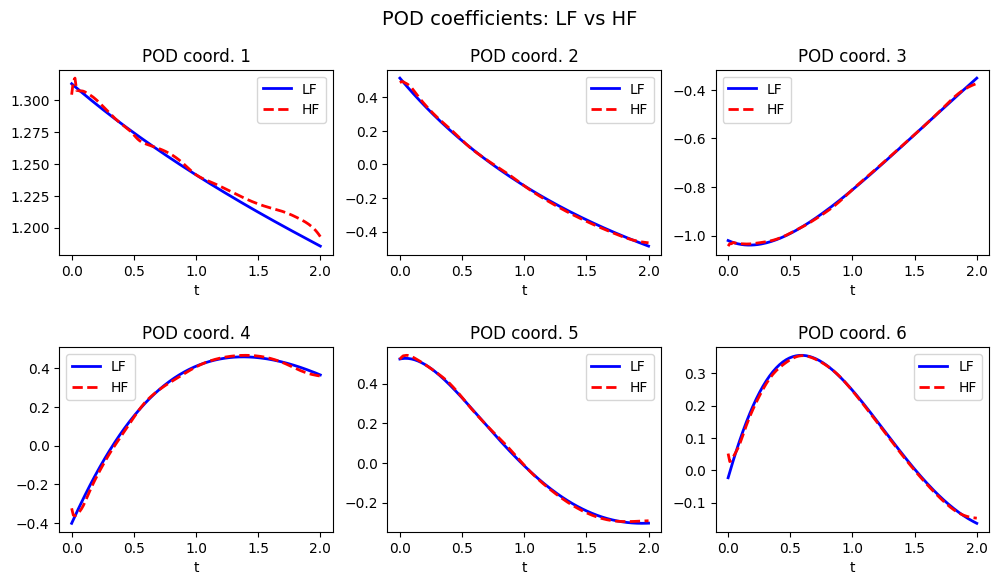

In [ ]:
ind_re = [0]
rom.plot_POD_output(ind_re=ind_re, output_pred=output_pred)


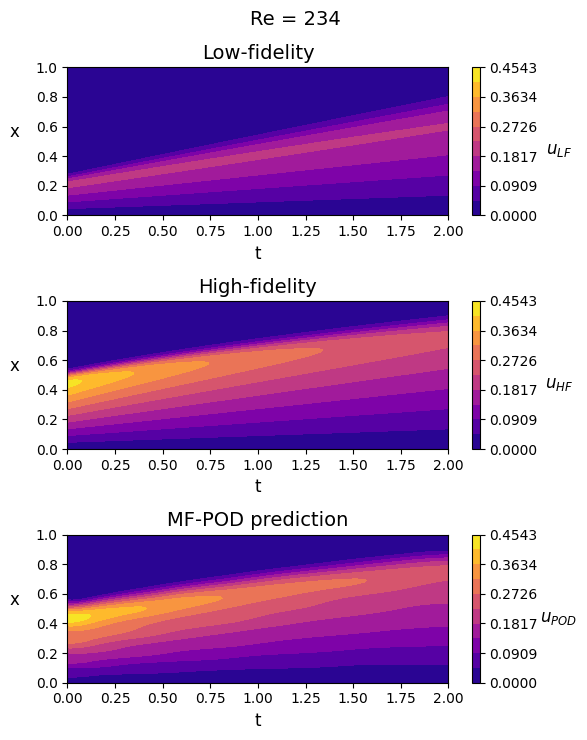

In [ ]:
burger_eq.plot_comparison(output_pred, rom.get_basis(), ind_re)


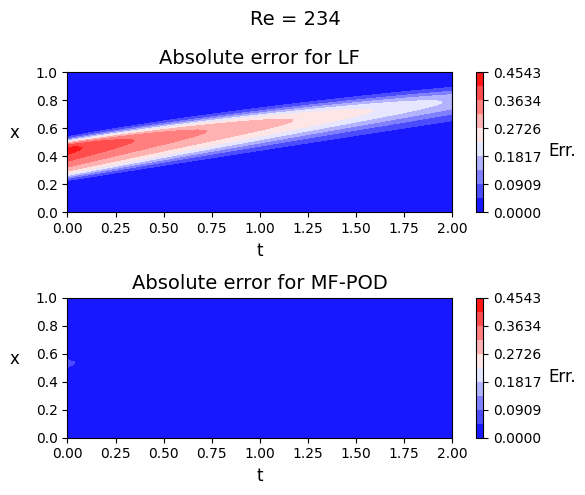

In [ ]:
burger_eq.plot_error(output_pred, rom.get_basis(), ind_re)


In [ ]:
from itertools import product


In [46]:
[rom.re_grid_lstm_test[0,0]]

[0.3684210526315789]

In [ ]:
burger_eq.set_POD(16,rom.get_basis())

Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [08:44<00:00,  5.72it/s]


Sampling chain 2/2


Running chain, α = 0.36: 100%|██████████| 3000/3000 [10:17<00:00,  4.86it/s]

Estimated values are [0.183]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.183  0.037   0.116     0.25      0.002    0.001     322.0     318.0   

    r_hat  
x0   1.01  



c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


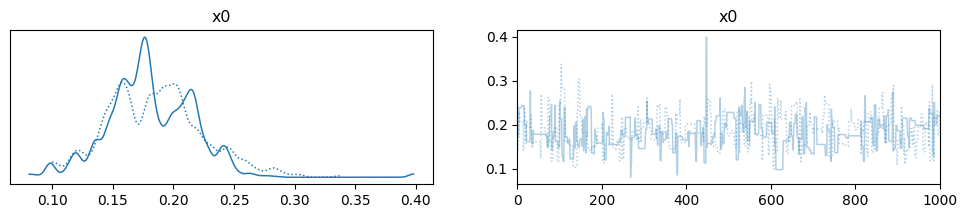

The difference between estimated values [0.18542105]



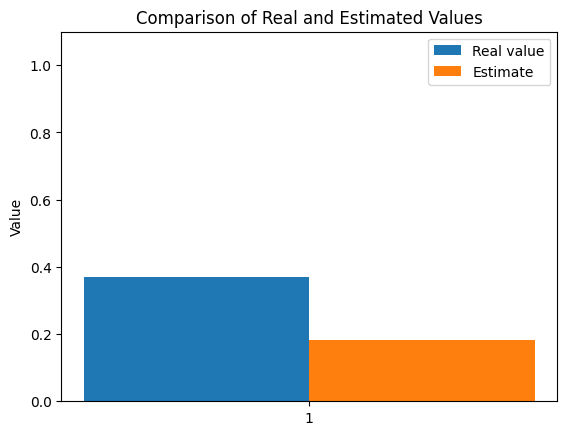

The function param_inverse took 1143.739303 seconds.
Sampling chain 1/2


Running chain, α = 0.23:  68%|██████▊   | 2046/3000 [06:26<03:00,  5.30it/s]


KeyboardInterrupt: 

In [12]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110,80]
index_re=0
parameter=np.array([rom.re_grid_lstm_test[index_re,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.45])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.3,0.5])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =3000
burnin = 2000
n_chains=2
#burger_eq.set_POD(n_POD,basis)
algo="MH"
module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


estimateMF, errorMF, param_MF= run_simulation(datahf_x=burger_eq.x, 
                                    datahf=rom.input_train[:,:,[0,1]].reshape(-1, 2), 
                                    mean_prior=mean_prior, 
                                    cov_prior=cov_prior, 
                                    Yhf=output_train[index_re,], 
                                    sigma_noise=sigma_noise, 
                                    n_data=n_data, 
                                    n_data_x=[101],
                                    parameters=parameter, 
                                    sigma=sigma, 
                                    rwmh_scaling=rmwh_scaling, 
                                    rwmh_cov=rwmh_cov, 
                                    rwmh_adaptive=rwmh_adaptive, 
                                    iterations=iterations, 
                                    burnin=burnin, 
                                    n_chains= n_chains, 
                                    final_model=model, 
                                    algo=algo, 
                                    force_sequential=True,
                                    forward_low_fidelity= burger_eq._forward_low_fidelity)

Sampling 2 chains in parallel


2024-08-16 10:21:06,417	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.351]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.351  0.26   0.035    0.837      0.014     0.01     320.0     411.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


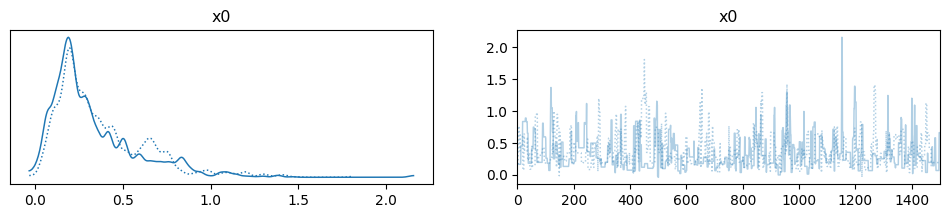

The difference between estimated values [0.01742105]



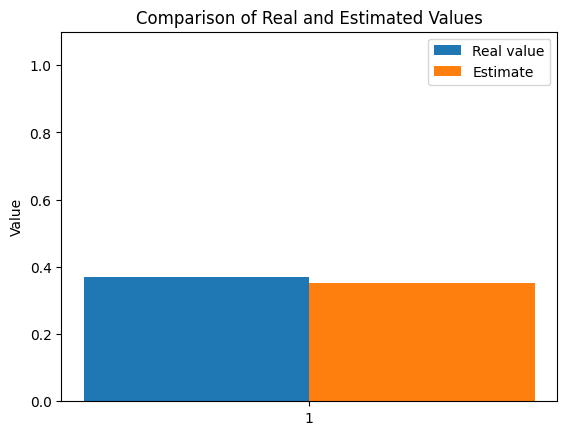

The function param_inverse took 1228.159030 seconds.
Sampling 2 chains in parallel


2024-08-16 10:41:15,397	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [-0.569]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0 -0.569  0.025  -0.612   -0.528      0.001    0.001     390.0     509.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


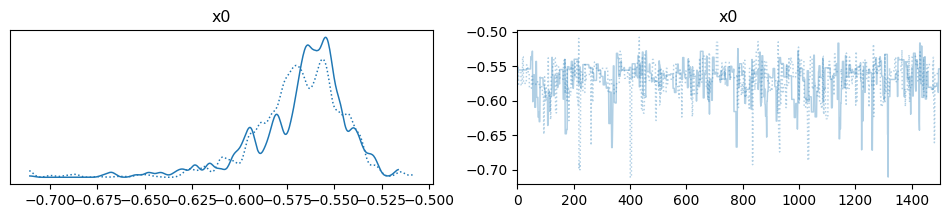

The difference between estimated values [0.93742105]



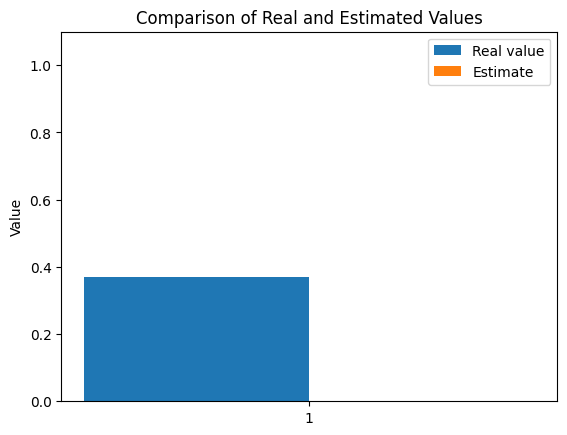

The function param_inverse took 1028.398814 seconds.
Sampling 2 chains in parallel


2024-08-16 10:58:30,149	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.374]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.374  0.27   0.029    0.936      0.015     0.01     337.0     385.0   

    r_hat  
x0   1.01  


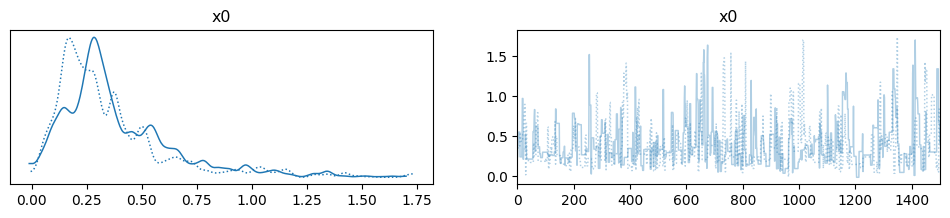

The difference between estimated values [0.00557895]



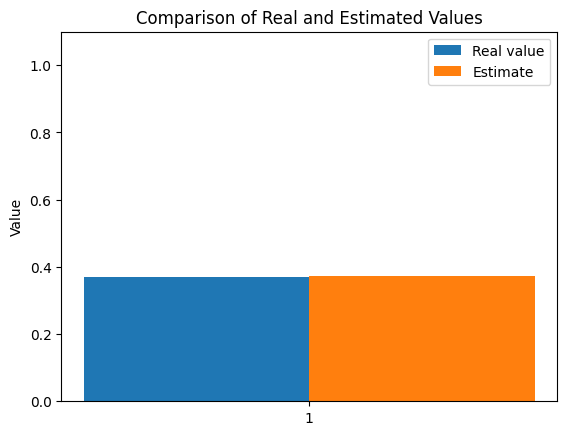

The function param_inverse took 994.292061 seconds.
Sampling 2 chains in parallel


2024-08-16 11:14:59,330	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.197]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.197  0.078   0.074    0.338      0.004    0.003     441.0     532.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


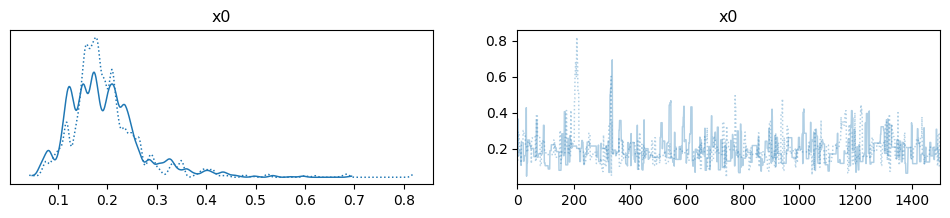

The difference between estimated values [0.17142105]



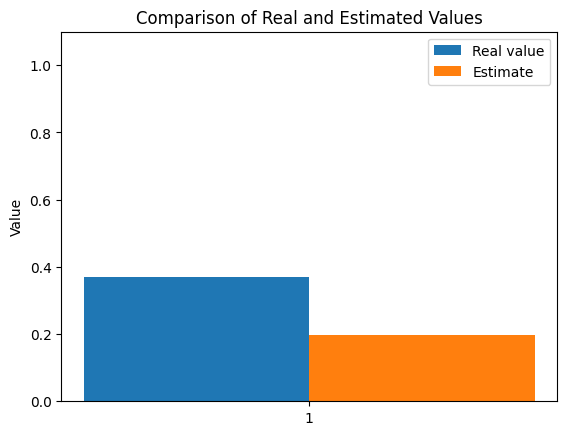

The function param_inverse took 960.488949 seconds.
Sampling 2 chains in parallel


2024-08-16 11:31:00,498	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.199]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.199  0.074   0.079    0.334      0.004    0.003     413.0     581.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


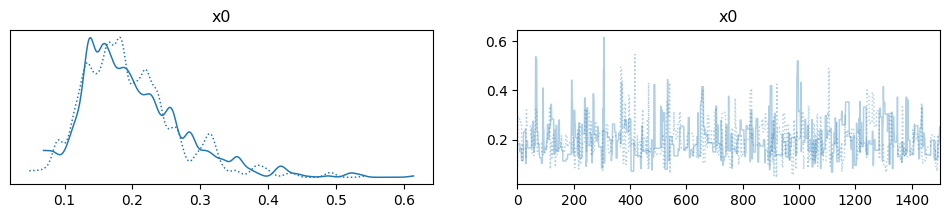

The difference between estimated values [0.16942105]



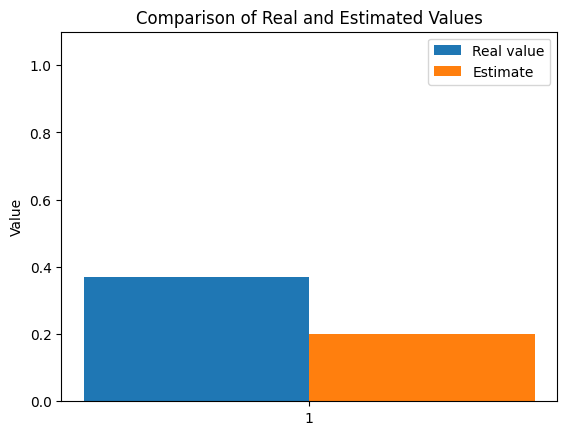

The function param_inverse took 1003.637507 seconds.
Sampling 2 chains in parallel


2024-08-16 11:47:43,218	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.202]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.202  0.076   0.078    0.339      0.004    0.003     413.0     453.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


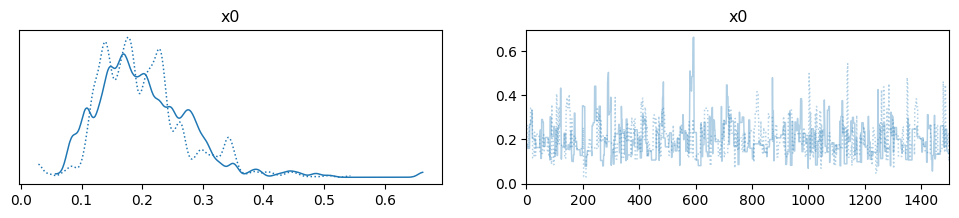

The difference between estimated values [0.16642105]



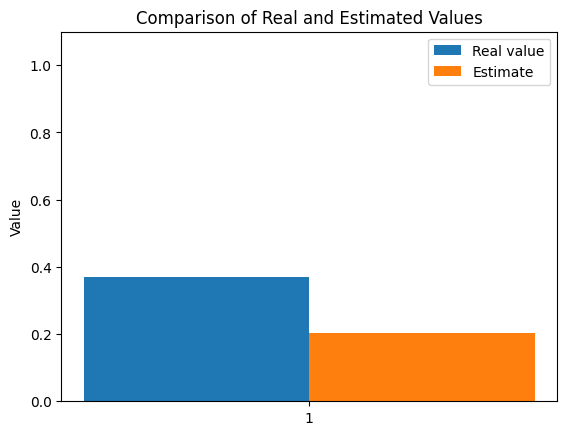

The function param_inverse took 1028.667358 seconds.
Sampling 2 chains in parallel


2024-08-16 12:04:54,582	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.326]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.326  0.275  -0.045    0.841      0.014     0.01     412.0     532.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


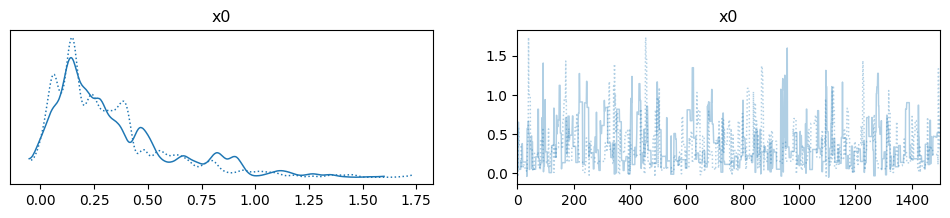

The difference between estimated values [0.04242105]



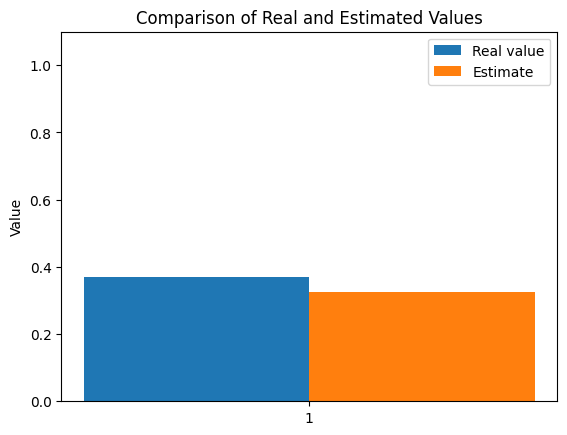

The function param_inverse took 802.265945 seconds.
Sampling 2 chains in parallel


2024-08-16 12:18:13,358	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.321]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.321  0.265  -0.042    0.838      0.014     0.01     365.0     485.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


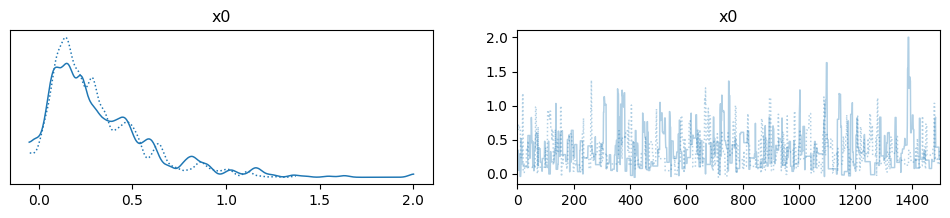

The difference between estimated values [0.04742105]



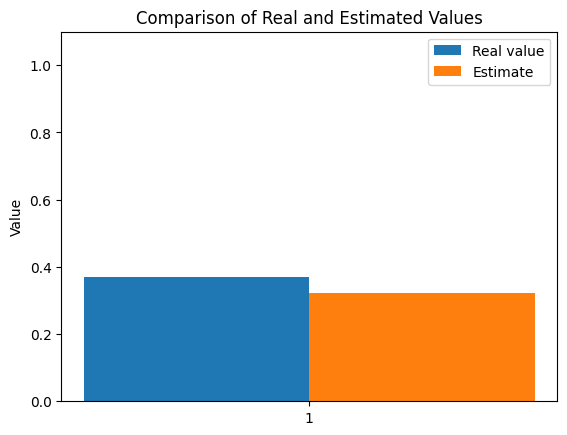

The function param_inverse took 769.691439 seconds.
Sampling 2 chains in parallel


2024-08-16 12:31:07,325	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.304]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.304  0.261  -0.036    0.829      0.014     0.01     389.0     543.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


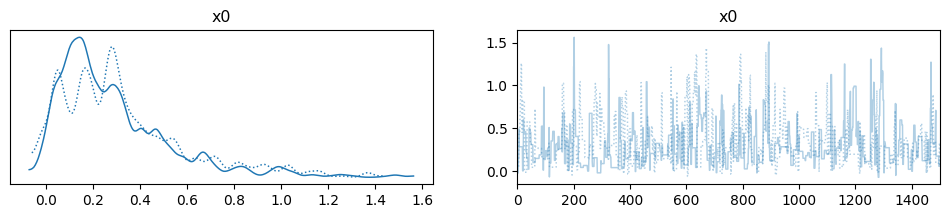

The difference between estimated values [0.06442105]



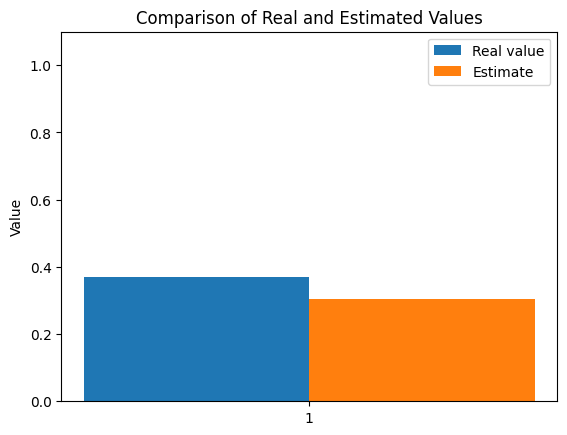

The function param_inverse took 740.510154 seconds.
Sampling 2 chains in parallel


2024-08-16 12:43:25,274	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.155]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.155  0.089   0.003    0.315      0.005    0.003     404.0     387.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


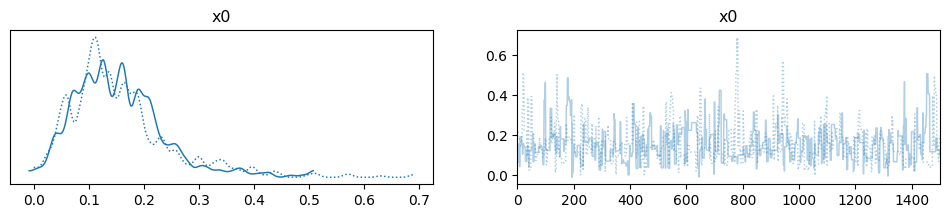

The difference between estimated values [0.21342105]



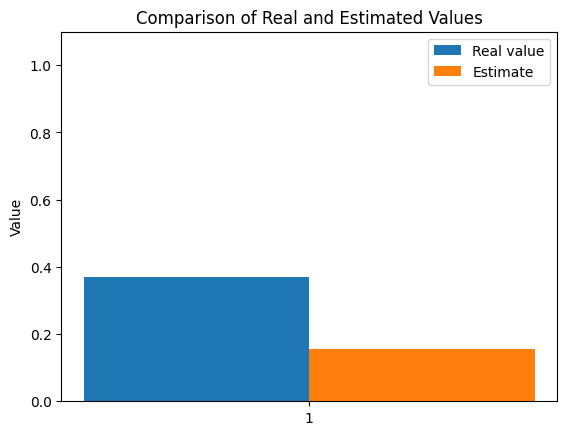

The function param_inverse took 750.277489 seconds.
Sampling 2 chains in parallel


2024-08-16 12:55:53,981	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.133]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.133  0.087   0.002    0.282      0.006    0.004     274.0     262.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


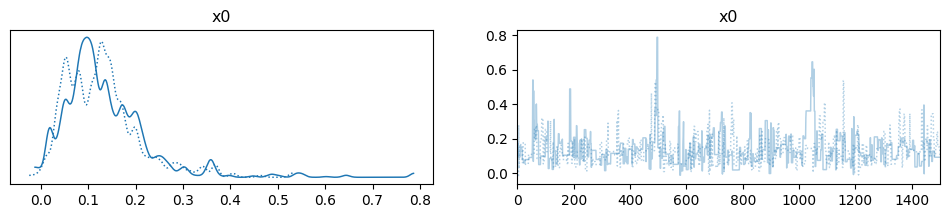

The difference between estimated values [0.23542105]



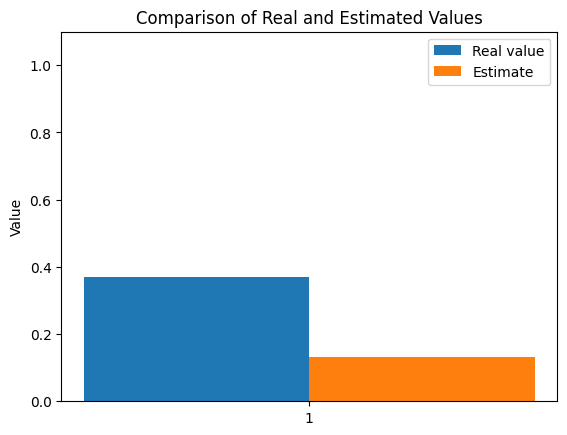

The function param_inverse took 747.409140 seconds.
Sampling 2 chains in parallel


2024-08-16 13:08:21,219	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.149]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.149  0.081   0.028    0.306      0.004    0.003     465.0     486.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


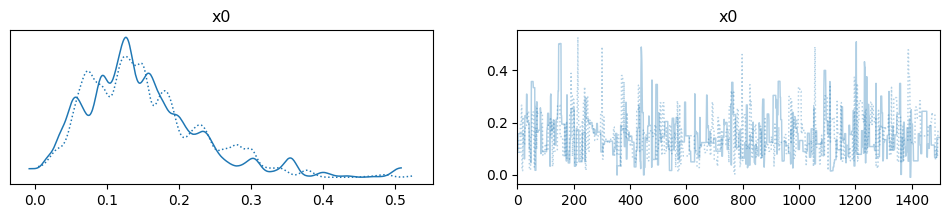

The difference between estimated values [0.21942105]



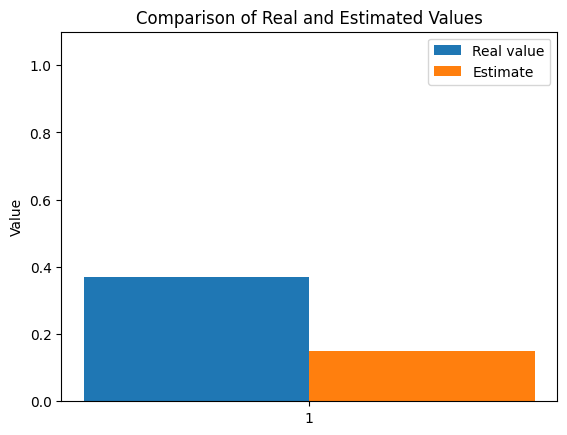

The function param_inverse took 758.298859 seconds.
Sampling 2 chains in parallel


2024-08-16 13:21:09,221	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.339]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.339  0.272   0.001    0.793      0.013    0.009     389.0     362.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


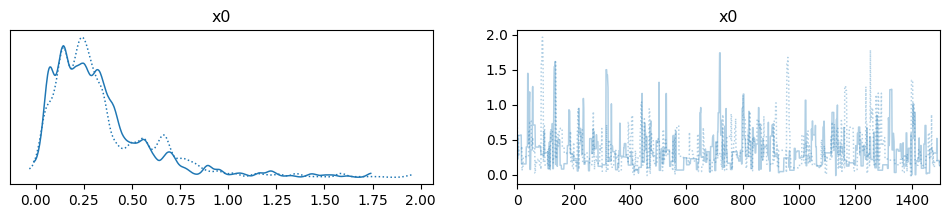

The difference between estimated values [0.02942105]



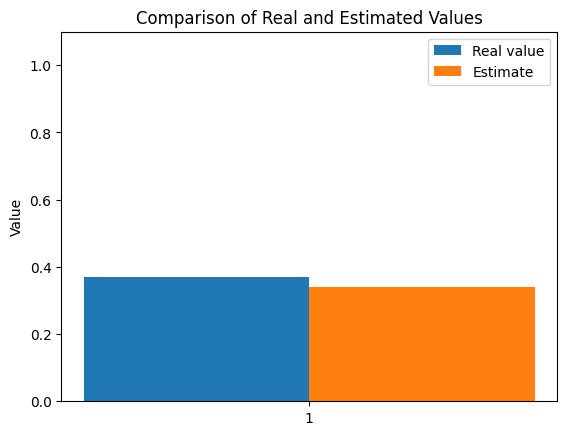

The function param_inverse took 972.446732 seconds.
Sampling 2 chains in parallel


2024-08-16 13:37:11,953	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.392]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.392  0.268   0.028    0.915      0.016    0.011     304.0     452.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


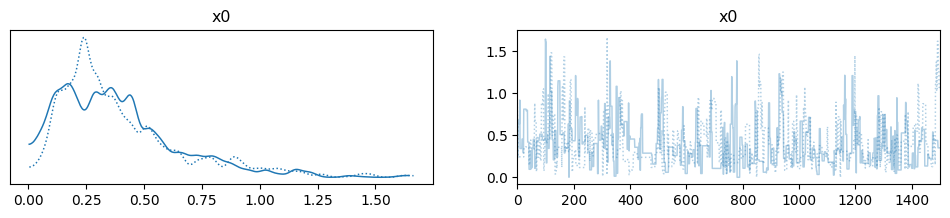

The difference between estimated values [0.02357895]



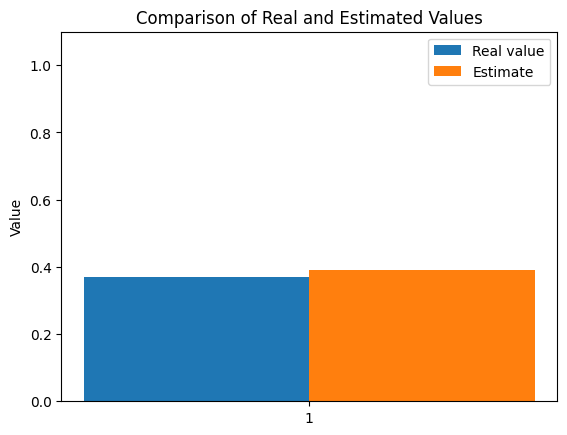

The function param_inverse took 928.319127 seconds.
Sampling 2 chains in parallel


2024-08-16 13:52:40,401	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.353]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.353  0.247   0.015    0.855      0.013    0.009     351.0     496.0   

    r_hat  
x0    1.0  


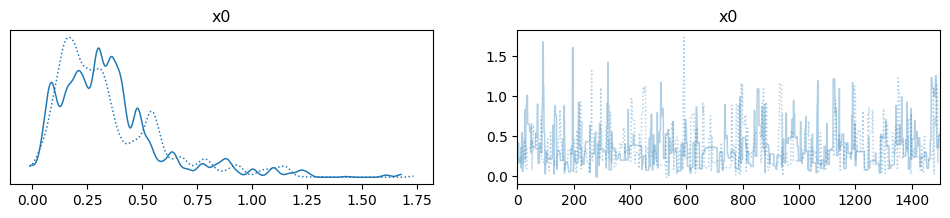

The difference between estimated values [0.01542105]



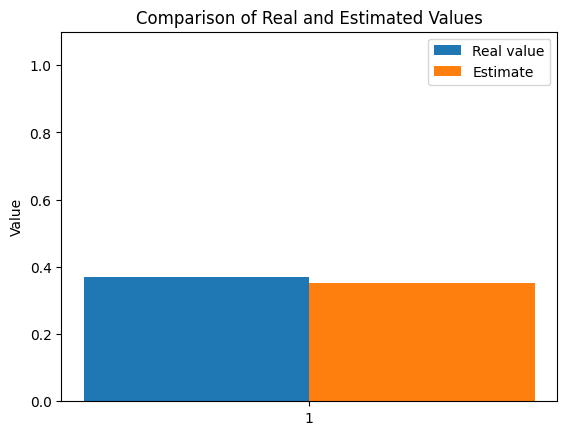

The function param_inverse took 1130.975189 seconds.
Sampling 2 chains in parallel


2024-08-16 14:12:59,415	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.175]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.175  0.065   0.064    0.298      0.003    0.002     515.0     402.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


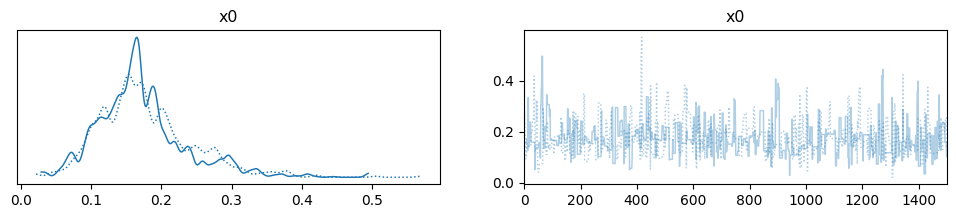

The difference between estimated values [0.19342105]



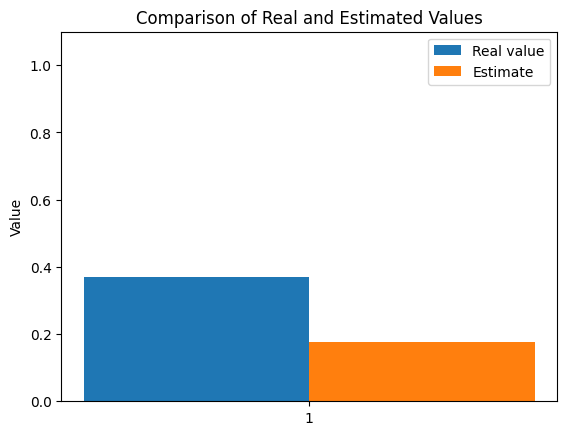

The function param_inverse took 1036.478642 seconds.
Sampling 2 chains in parallel


2024-08-16 14:28:48,429	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.181]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.181  0.071   0.082    0.328      0.003    0.002     431.0     578.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


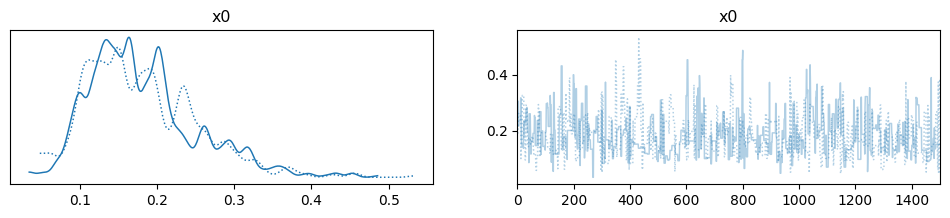

The difference between estimated values [0.18742105]



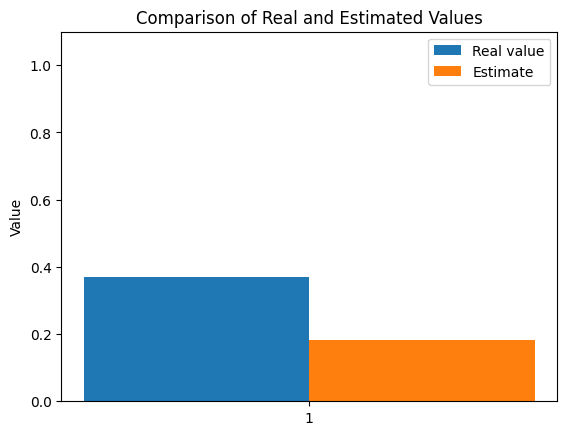

The function param_inverse took 1030.118726 seconds.
Sampling 2 chains in parallel


2024-08-16 14:46:02,675	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.2]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0   0.2  0.073   0.079    0.335      0.003    0.002     428.0     409.0   

    r_hat  
x0   1.01  


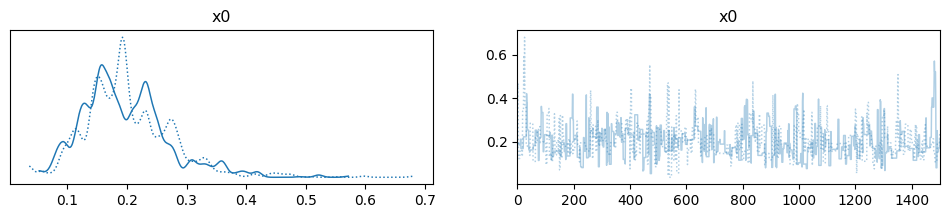

The difference between estimated values [0.16842105]



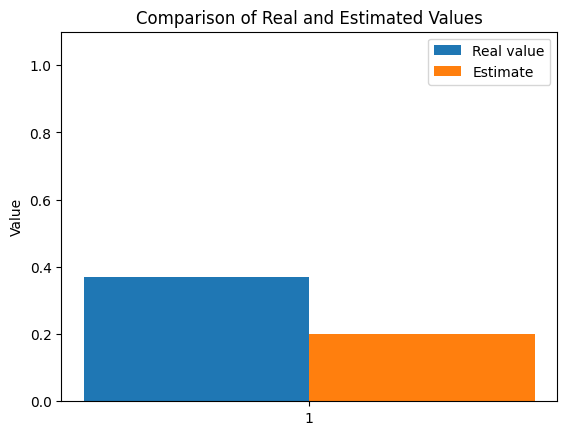

The function param_inverse took 2459.739224 seconds.
Sampling 2 chains in parallel


2024-08-16 15:27:01,299	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.273]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.273  0.253  -0.043    0.767      0.014     0.01     329.0     376.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


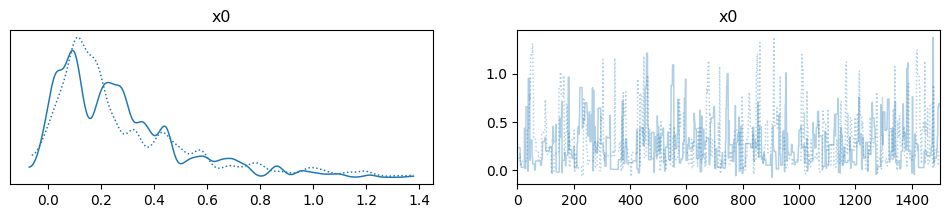

The difference between estimated values [0.09542105]



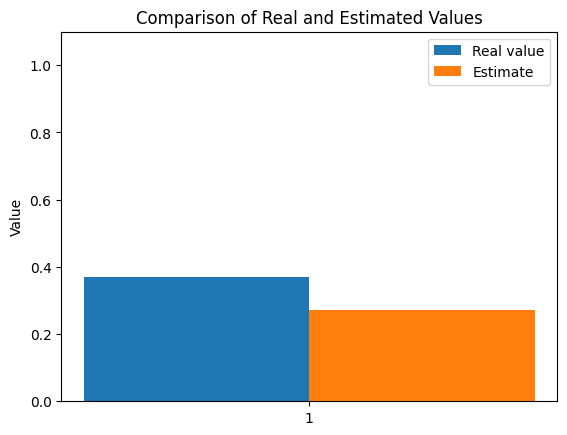

The function param_inverse took 928.865747 seconds.
Sampling 2 chains in parallel


2024-08-16 15:42:27,797	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.334]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.334  0.266  -0.023    0.795      0.016    0.012     320.0     307.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


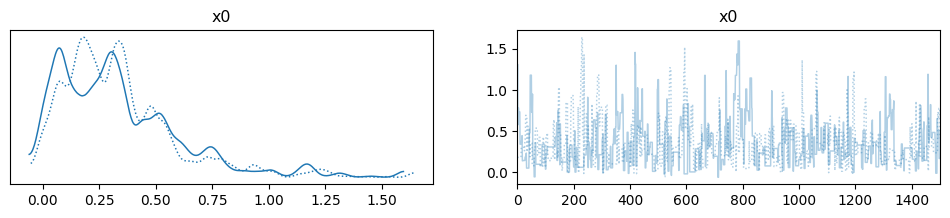

The difference between estimated values [0.03442105]



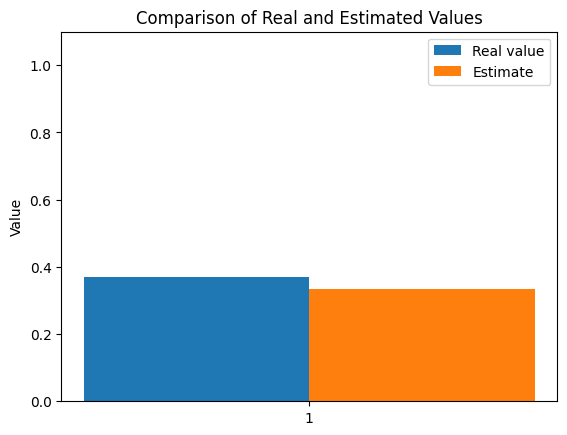

The function param_inverse took 964.951627 seconds.
Sampling 2 chains in parallel


2024-08-16 15:58:44,815	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.35]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.35  0.281  -0.041    0.871      0.015     0.01     386.0     508.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


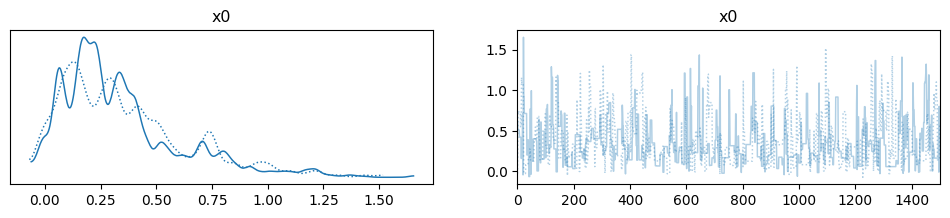

The difference between estimated values [0.01842105]



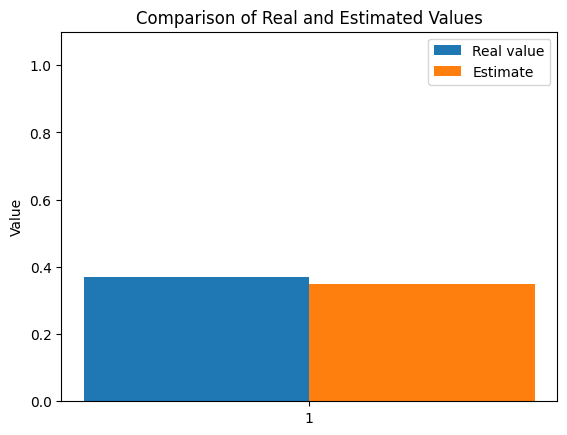

The function param_inverse took 836.363491 seconds.
Sampling 2 chains in parallel


2024-08-16 16:12:28,406	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.134]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.134  0.084    -0.0    0.283      0.004    0.003     419.0     445.0   

    r_hat  
x0   1.01  


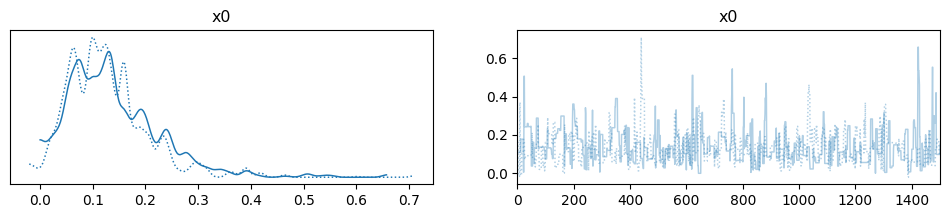

The difference between estimated values [0.23442105]



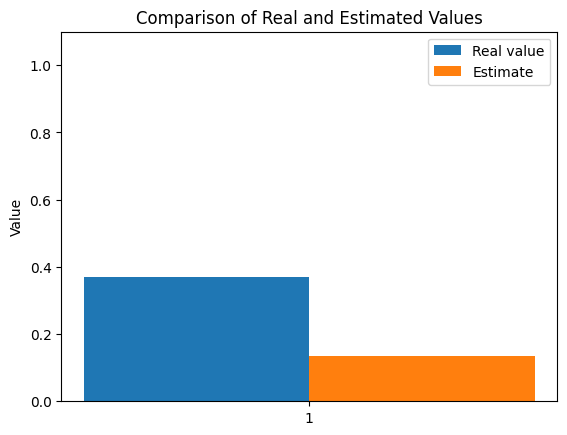

The function param_inverse took 1235.006576 seconds.
Sampling 2 chains in parallel


2024-08-16 16:33:43,263	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.112]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.112  0.068   0.005    0.245      0.004    0.003     339.0     365.0   

    r_hat  
x0    1.0  


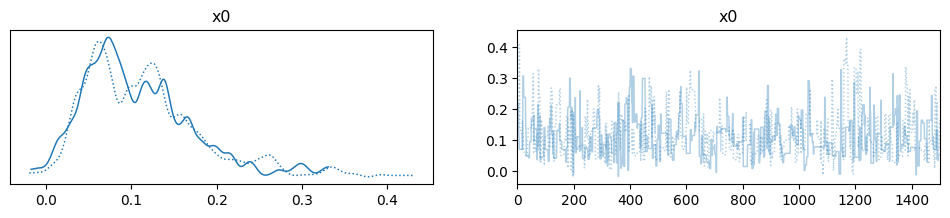

The difference between estimated values [0.25642105]



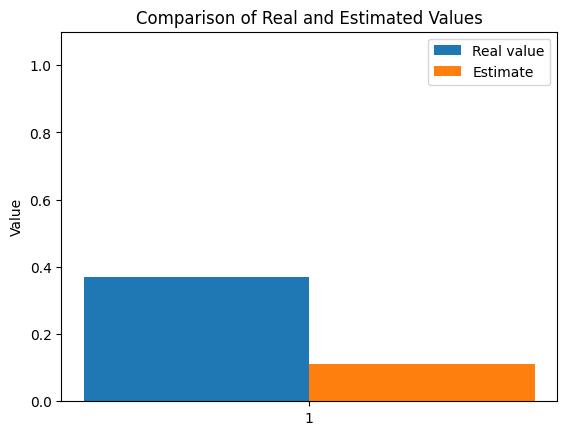

The function param_inverse took 1322.378815 seconds.
Sampling 2 chains in parallel


2024-08-16 16:55:29,566	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [0.112]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.112  0.073    -0.0    0.236      0.004    0.003     372.0     479.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


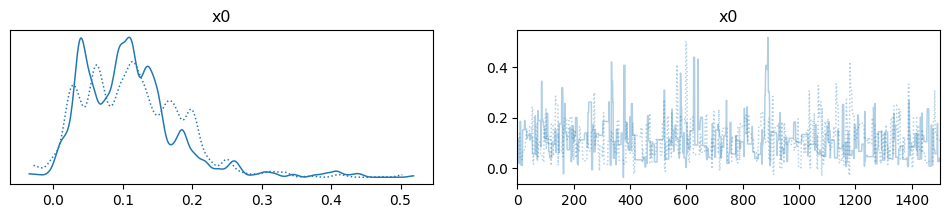

The difference between estimated values [0.25642105]



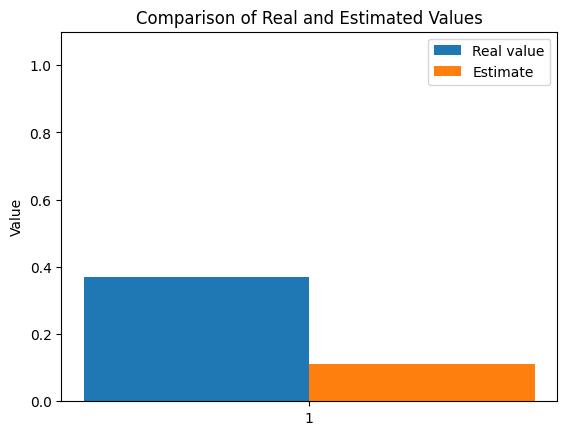

The function param_inverse took 1102.206309 seconds.
The best estimate is given by: sigma_noise=0.05, number of data=110, sigma=1.0, rwmh_scaling=0.1


ValueError: too many values to unpack (expected 2)

In [16]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110,80]
index_re=0
parameter=np.array([rom.re_grid_lstm_test[index_re,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.45])
cov_prior=np.diag([.2])
# cov_linkelihood
sigma=np.array([1.,0.5])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1, 0.05,0.25])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =4000
burnin = 2500
n_chains=2
#burger_eq.set_POD(n_POD,basis)
algo="MH"
module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


estimateMF, errorMF, param_MF= run_simulation(datahf_x=burger_eq.x, 
                                    datahf=rom.input_train[:,:,[0,1]].reshape(-1, 2), 
                                    mean_prior=mean_prior, 
                                    cov_prior=cov_prior, 
                                    Yhf=output_train[index_re,], 
                                    sigma_noise=sigma_noise, 
                                    n_data=n_data, 
                                    n_data_x=[101],
                                    parameters=parameter, 
                                    sigma=sigma, 
                                    rwmh_scaling=rmwh_scaling, 
                                    rwmh_cov=rwmh_cov, 
                                    rwmh_adaptive=rwmh_adaptive, 
                                    iterations=iterations, 
                                    burnin=burnin, 
                                    n_chains= n_chains, 
                                    final_model=model, 
                                    algo=algo, 
                                    force_sequential=False,
                                    forward_low_fidelity= burger_eq._forward_low_fidelity)

In [ ]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110,80]
index_re=2
parameter=np.array([rom.re_grid_lstm_test[index_re,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.45])
cov_prior=np.diag([.2])
# cov_linkelihood
sigma=np.array([1.,0.5])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.1, 0.05,0.25])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =4000
burnin = 2500
n_chains=2
#burger_eq.set_POD(n_POD,basis)
algo="MH"
module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


estimateMF, errorMF, param_MF= run_simulation(datahf_x=burger_eq.x, 
                                    datahf=rom.input_train[:,:,[0,1]].reshape(-1, 2), 
                                    mean_prior=mean_prior, 
                                    cov_prior=cov_prior, 
                                    Yhf=output_train[index_re,], 
                                    sigma_noise=sigma_noise, 
                                    n_data=n_data, 
                                    n_data_x=[101],
                                    parameters=parameter, 
                                    sigma=sigma, 
                                    rwmh_scaling=rmwh_scaling, 
                                    rwmh_cov=rwmh_cov, 
                                    rwmh_adaptive=rwmh_adaptive, 
                                    iterations=iterations, 
                                    burnin=burnin, 
                                    n_chains= n_chains, 
                                    final_model=model, 
                                    algo=algo, 
                                    force_sequential=False,
                                    forward_low_fidelity= burger_eq._forward_low_fidelity)

In [ ]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110,80]
index_re=-1
parameter=np.array([rom.re_grid_lstm_test[index_re,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.3,0.5])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =30
burnin = 20
n_chains=2
#burger_eq.set_POD(n_POD,basis)
algo="MH"
module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


estimateMF, errorMF= run_simulation(datahf_x=burger_eq.x, 
                                    datahf=rom.input_train[:,:,[0,1]].reshape(-1, 2), 
                                    mean_prior=mean_prior, 
                                    cov_prior=cov_prior, 
                                    Yhf=output_train[index_re,], 
                                    sigma_noise=sigma_noise, 
                                    n_data=n_data, 
                                    n_data_x=[101],
                                    parameters=parameter, 
                                    sigma=sigma, 
                                    rwmh_scaling=rmwh_scaling, 
                                    rwmh_cov=rwmh_cov, 
                                    rwmh_adaptive=rwmh_adaptive, 
                                    iterations=iterations, 
                                    burnin=burnin, 
                                    n_chains= n_chains, 
                                    final_model=model, 
                                    algo=algo, 
                                    force_sequential=True,
                                    forward_low_fidelity= burger_eq._forward_low_fidelity)

In [9]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 300
burnin = 200
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)


NameError: name 'x_HF' is not defined